# Random Forest Model Training


## Load Cleaned Data


In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

clean_train = pd.read_csv('data/clean_train_rolling.csv')
clean_val = pd.read_csv('data/clean_val_rolling.csv')

metadata_cols = ['Place_ID', 'Date', 'Place_ID X Date']
drop_cols = ['target'] + [col for col in metadata_cols if col in clean_train.columns]

X_tr = clean_train.drop(columns=drop_cols)
y_tr = clean_train['target']
X_val = clean_val.drop(columns=drop_cols)
y_val = clean_val['target']

print('X_tr shape:', X_tr.shape)
print('X_val shape:', X_val.shape)
print('y_tr shape:', y_tr.shape)
print('y_val shape:', y_val.shape)
clean_train.head()


X_tr shape: (24546, 24)
X_val shape: (6011, 24)
y_tr shape: (24546,)
y_val shape: (6011,)


,wind_speed_10m_above_ground,L3_AER_AI_sensor_altitude,L3_NO2_NO2_column_number_density,L3_NO2_NO2_slant_column_number_density,L3_CO_CO_column_number_density,L3_NO2_tropopause_pressure,relative_humidity_2m_above_ground,L3_HCHO_tropospheric_HCHO_column_number_density,wind_speed_10m_above_ground_place_roll_3,L3_AER_AI_sensor_altitude_place_roll_3,...,L3_HCHO_tropospheric_HCHO_column_number_density_place_roll_3,wind_speed_10m_above_ground_place_roll_7,L3_AER_AI_sensor_altitude_place_roll_7,L3_NO2_NO2_column_number_density_place_roll_7,L3_NO2_NO2_slant_column_number_density_place_roll_7,L3_CO_CO_column_number_density_place_roll_7,L3_NO2_tropopause_pressure_place_roll_7,relative_humidity_2m_above_ground_place_roll_7,L3_HCHO_tropospheric_HCHO_column_number_density_place_roll_7,target
0,2.343506,840209.874619,0.000074,0.000156,0.021080,6156.074219,60.200001,0.000064,2.748319,832006.190946,...,0.000072,2.812193,832010.232056,0.000083,0.000158,0.035648,15799.374982,73.780511,0.000070,38.0
1,3.536009,840772.941995,0.000076,0.000197,0.022017,6156.074219,48.799999,0.000171,2.343506,840209.874619,...,0.000064,2.343506,840209.874619,0.000074,0.000156,0.021080,6156.074219,60.200001,0.000064,39.0
2,6.157557,841410.713456,0.000067,0.000170,0.020677,7311.869141,33.400002,0.000124,2.939757,840491.408307,...,0.000117,2.939757,840491.408307,0.000075,0.000176,0.021548,6156.074219,54.500000,0.000117,24.0
3,3.198883,841103.242368,0.000083,0.000175,0.021207,11205.388333,21.306429,0.000081,4.012357,840797.843357,...,0.000120,4.012357,840797.843357,0.000072,0.000174,0.021258,6541.339193,47.466667,0.000120,49.0
4,3.742413,840763.055499,0.000070,0.000142,0.037766,11205.372845,44.700001,0.000140,4.297483,841095.632606,...,0.000125,3.808989,840874.193109,0.000075,0.000174,0.021245,7707.351478,40.925001,0.000110,21.0


## Target Skewness


Skewness: 2.09


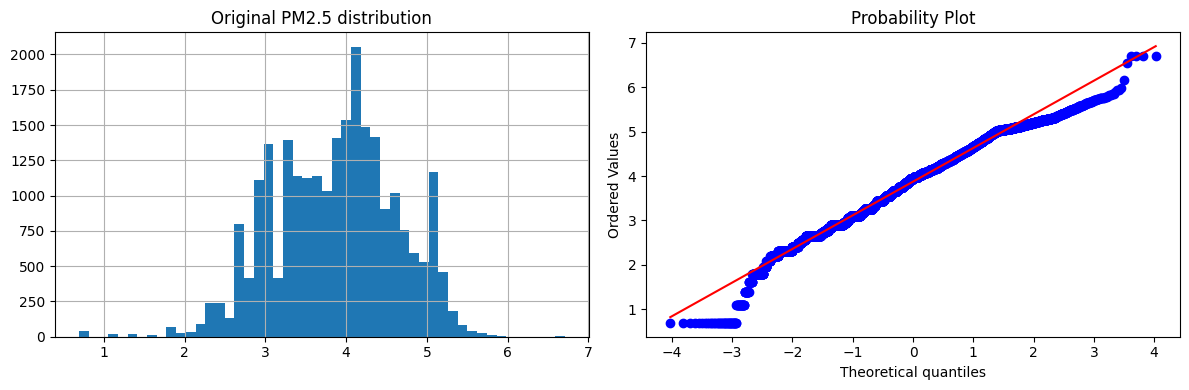

In [13]:
#Handle the target skewness by applying a log transform

import scipy.stats as stats

print(f"Skewness: {y_tr.skew():.2f}")



# Apply log transform
y_tr_log  = np.log1p(y_tr.reset_index(drop=True))
y_val_log = np.log1p(y_val.reset_index(drop=True))
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
y_tr_log.hist(bins=50, ax=axes[0])
axes[0].set_title("Original PM2.5 distribution")
stats.probplot(y_tr_log, plot=axes[1])
plt.tight_layout()
plt.show()


In [14]:
# Now we apply Randomforest Regressor 
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import RandomizedSearchCV
from math import prod

# Step 1 — feature selection using RF importance
rf_selector = RandomForestRegressor(n_estimators=100,
                                    random_state=42,
                                    n_jobs=-1,
                                    max_depth=15,
                                    min_samples_split=10,
                                    min_samples_leaf=5,
                                    max_leaf_nodes=None)
rf_selector.fit(X_tr, y_tr_log)

importance = pd.Series(rf_selector.feature_importances_, index=X_tr.columns)
top_features = importance.sort_values(ascending=False).head(25).index.tolist()

print("Top 25 features:")
print(importance.sort_values(ascending=False).head(25))

# Step 2 — select top features
X_tr_selected = X_tr[top_features]
X_val_selected = X_val[top_features]






Top 25 features:
L3_CO_CO_column_number_density_place_roll_7                     0.203434
wind_speed_10m_above_ground                                     0.119707
L3_AER_AI_sensor_altitude_place_roll_7                          0.111729
L3_HCHO_tropospheric_HCHO_column_number_density_place_roll_7    0.080172
L3_NO2_NO2_slant_column_number_density_place_roll_7             0.041575
wind_speed_10m_above_ground_place_roll_7                        0.037713
L3_AER_AI_sensor_altitude                                       0.035656
L3_NO2_NO2_column_number_density                                0.033743
relative_humidity_2m_above_ground_place_roll_7                  0.032550
L3_NO2_NO2_slant_column_number_density_place_roll_3             0.032048
L3_AER_AI_sensor_altitude_place_roll_3                          0.029458
L3_NO2_NO2_slant_column_number_density                          0.027463
L3_NO2_tropopause_pressure_place_roll_7                         0.024685
L3_CO_CO_column_number_density    

In [ ]:
# Optional: tune Random Forest pruning parameters with randomized search.
# Keep this False unless you explicitly want to rerun the expensive HP search.
RUN_HYPERPARAMETER_SEARCH = False

if RUN_HYPERPARAMETER_SEARCH:
    rf_model = RandomForestRegressor(random_state=42, n_jobs=-1)

    param_distributions = {
        "n_estimators": [200, 300, 500],
        "max_depth": [8, 12, 16, 20, None],
        "min_samples_leaf": [1, 2, 3, 5, 10],
        "min_samples_split": [2, 5, 10, 20],
        "max_features": ["sqrt", 0.5, 0.8, 1.0],
        "max_leaf_nodes": [None, 50, 100, 200, 500],
    }

    total_possible_combinations = prod(len(values) for values in param_distributions.values())
    n_iter = 30
    print(f"Total possible hyperparameter combinations: {total_possible_combinations}")
    print(f"RandomizedSearchCV will test: {n_iter} combinations")

    search = RandomizedSearchCV(
        estimator=rf_model,
        param_distributions=param_distributions,
        n_iter=n_iter,
        scoring="neg_root_mean_squared_error",
        cv=3,
        random_state=42,
        n_jobs=-1,
        verbose=2,
    )

    search.fit(X_tr_selected, y_tr_log)

    best_params = search.best_params_
    best_cv_rmse_log = -search.best_score_
    print(best_params)
else:
    print("Skipping hyperparameter search. Using saved best_params in the next cell.")


Total possible hyperparameter combinations: 6000
RandomizedSearchCV will test: 30 combinations
Fitting 3 folds for each of 30 candidates, totalling 90 fits
[CV] END max_depth=None, max_features=0.5, max_leaf_nodes=100, min_samples_leaf=1, min_samples_split=10, n_estimators=200; total time=  12.3s
[CV] END max_depth=None, max_features=0.5, max_leaf_nodes=100, min_samples_leaf=1, min_samples_split=10, n_estimators=200; total time=  12.9s
[CV] END max_depth=None, max_features=0.5, max_leaf_nodes=100, min_samples_leaf=1, min_samples_split=10, n_estimators=200; total time=  13.2s
[CV] END max_depth=None, max_features=0.5, max_leaf_nodes=50, min_samples_leaf=3, min_samples_split=10, n_estimators=300; total time=  17.0s
[CV] END max_depth=None, max_features=0.5, max_leaf_nodes=50, min_samples_leaf=3, min_samples_split=10, n_estimators=300; total time=  17.2s
[CV] END max_depth=None, max_features=0.5, max_leaf_nodes=50, min_samples_leaf=3, min_samples_split=10, n_estimators=300; total time=  1

In [15]:
# Use the best hyperparameters found earlier, without rerunning RandomizedSearchCV.
best_params = {
    "n_estimators": 300,
    "min_samples_split": 10,
    "min_samples_leaf": 5,
    "max_leaf_nodes": None,
    "max_features": "sqrt",
    "max_depth": None,
}

best_rf = RandomForestRegressor(
    **best_params,
    random_state=42,
    n_jobs=-1,
)

best_rf.fit(X_tr_selected, y_tr_log)
y_val_pred = np.expm1(best_rf.predict(X_val_selected))

rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
mean_pm25 = y_tr.mean()

print("Best Random Forest hyperparameters:")
for param, value in best_params.items():
    print(f"{param}: {value}")

print(f"\nValidation RMSE: {rmse:.2f} µg/m³")
print(f"Mean PM2.5: {mean_pm25:.2f} µg/m³")
print(f"RMSE as % of mean: {(rmse / mean_pm25) * 100:.1f}%")


Best Random Forest hyperparameters:
n_estimators: 300
min_samples_split: 10
min_samples_leaf: 5
max_leaf_nodes: None
max_features: sqrt
max_depth: None

Validation RMSE: 30.05 µg/m³
Mean PM2.5: 62.03 µg/m³
RMSE as % of mean: 48.4%


In [7]:
print(y_tr.describe())
print("Best hyperparameters:")
for param, value in best_params.items():
    print(f"{param}: {value}")


count    24546.000000
mean        62.030995
std         47.960782
min          1.000000
25%         26.000000
50%         51.000000
75%         80.000000
max        815.000000
Name: target, dtype: float64
Best hyperparameters:
n_estimators: 300
min_samples_split: 10
min_samples_leaf: 5
max_leaf_nodes: None
max_features: sqrt
max_depth: None


## Feature Count Experiment


# Test different numbers of top features while keeping the best hyperparameters fixed
feature_ranking = importance.sort_values(ascending=False).index.tolist()

top_n_values = [5, 10, 15, 20, 25, 30, 40, 50, 60, len(feature_ranking)]
top_n_values = sorted(set(n for n in top_n_values if n <= len(feature_ranking)))

feature_count_results = []

fixed_rf_params = {
    **best_params,
    'random_state': 42,
    'n_jobs': -1,
}

for top_n in top_n_values:
    selected_features = feature_ranking[:top_n]

    rf_top_n = RandomForestRegressor(**fixed_rf_params)
    rf_top_n.fit(X_tr[selected_features], y_tr_log)

    y_val_pred = np.expm1(rf_top_n.predict(X_val[selected_features]))
    validation_rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))

    feature_count_results.append({
        'top_n_features': top_n,
        'validation_rmse': validation_rmse,
        'rmse_as_percent_of_mean': (validation_rmse / y_tr.mean()) * 100,
        'features': selected_features,
    })

    print(f"Top {top_n:>2} features -> Validation RMSE: {validation_rmse:.2f} µg/m³")

feature_count_results = pd.DataFrame(feature_count_results).sort_values('validation_rmse')

print()
print('Best feature count result:')
print(feature_count_results[['top_n_features', 'validation_rmse', 'rmse_as_percent_of_mean']].head(1))

feature_count_results[['top_n_features', 'validation_rmse', 'rmse_as_percent_of_mean']]


Running roll_1_days_past_only...
Running roll_1_days_with_current...
Running roll_2_days_past_only...
Running roll_2_days_with_current...
Running roll_3_days_past_only...
Running roll_3_days_with_current...
Running roll_4_days_past_only...
Running roll_4_days_with_current...
Running roll_5_days_past_only...
Running roll_5_days_with_current...
Running roll_6_days_past_only...
Running roll_6_days_with_current...
Running roll_7_days_past_only...
Running roll_7_days_with_current...
Running roll_8_days_past_only...
Running roll_8_days_with_current...
Running roll_9_days_past_only...
Running roll_9_days_with_current...
Running roll_10_days_past_only...
Running roll_10_days_with_current...
Best rolling configuration:
                   config  validation_rmse  validation_mae  validation_r2
0  roll_10_days_past_only        29.898305       19.578292       0.490387


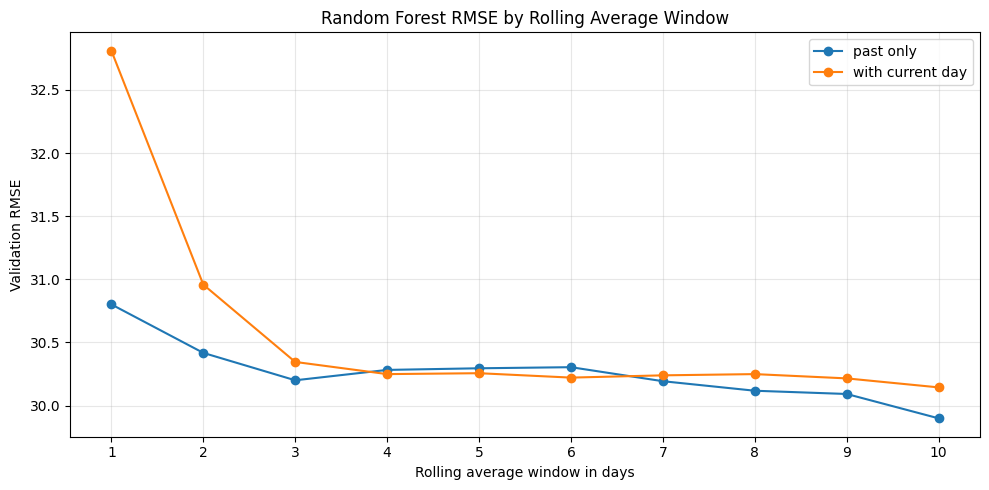

,config,rolling_window_days,include_current_day,validation_rmse,validation_mae,validation_r2
0,roll_10_days_past_only,10,False,29.898305,19.578292,0.490387
1,roll_9_days_past_only,9,False,30.091260,19.652210,0.483788
2,roll_8_days_past_only,8,False,30.116996,19.694666,0.482904
3,roll_10_days_with_current,10,True,30.143510,19.744860,0.481993
4,roll_7_days_past_only,7,False,30.192421,19.744488,0.480311
5,roll_3_days_past_only,3,False,30.199730,19.804163,0.480059
6,roll_9_days_with_current,9,True,30.214787,19.761959,0.479541
7,roll_6_days_with_current,6,True,30.221002,19.838710,0.479327
8,roll_7_days_with_current,7,True,30.238881,19.824431,0.478710
9,roll_4_days_with_current,4,True,30.248703,19.874462,0.478372


In [9]:
# Big rolling-window experiment: windows 1-10, with and without current day.
# This is self-contained so it does not depend on pre-saved rolling CSVs.
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

RANDOM_STATE = 42
TOP_N_FEATURES = 25
ROLLING_WINDOWS_TO_TEST = range(1, 11)
INCLUDE_CURRENT_OPTIONS = [False, True]

best_params = {
    "n_estimators": 300,
    "min_samples_split": 10,
    "min_samples_leaf": 5,
    "max_leaf_nodes": None,
    "max_features": "sqrt",
    "max_depth": None,
}

# Load raw train data because each config needs different rolling features.
df_base = pd.read_csv('data/Train.csv')
best_features = pd.read_csv('data/best_features.csv')

leakage_cols = ['target_min', 'target_max', 'target_variance', 'target_count']
high_missing_cols = df_base.columns[df_base.isnull().mean() >= 0.8].tolist()
calendar_cols = ['day_number', 'week', 'month', 'day_of_week']
angle_keywords = ['azimuth_angle', 'zenith_angle']
skewness_threshold = 2

# Match the main cleaning notebook feature engineering.
df_base['Date'] = pd.to_datetime(df_base['Date'])
df_base['day_number'] = (df_base['Date'] - df_base['Date'].min()).dt.days + 1
df_base['week'] = ((df_base['day_number'] - 1) // 7) + 1
df_base['month'] = df_base['Date'].dt.month
df_base['day_of_week'] = df_base['Date'].dt.dayofweek

u_wind_col = 'u_component_of_wind_10m_above_ground'
v_wind_col = 'v_component_of_wind_10m_above_ground'
df_base['wind_speed_10m_above_ground'] = np.sqrt(
    df_base[u_wind_col] ** 2 + df_base[v_wind_col] ** 2
)
df_base = df_base.drop(columns=[u_wind_col, v_wind_col])

# Use the Random Forest feature list, but map old u/v wind names to wind speed.
wind_component_cols = [u_wind_col, v_wind_col]
rf_top_features = best_features['random_forest'].dropna().tolist()
rf_top_features = [
    'wind_speed_10m_above_ground' if col in wind_component_cols else col
    for col in rf_top_features
]
rf_top_features = list(dict.fromkeys(rf_top_features))

base_feature_cols = [
    col for col in rf_top_features
    if col in df_base.columns
    and col not in leakage_cols + high_missing_cols + ['target']
]

rolling_base_cols = [
    col for col in base_feature_cols
    if col not in calendar_cols
]

# Same place-based validation split as the cleaning notebook.
places_train, places_val = train_test_split(
    df_base['Place_ID'].unique(),
    test_size=0.2,
    random_state=RANDOM_STATE,
)

train_base = df_base[df_base['Place_ID'].isin(places_train)].copy()
val_base = df_base[df_base['Place_ID'].isin(places_val)].copy()

def add_rolling_features(df, base_cols, window, include_current):
    df = df.sort_values(['Place_ID', 'Date']).copy()
    suffix = 'with_current' if include_current else 'past_only'

    for col in base_cols:
        grouped = df.groupby('Place_ID')[col]
        if include_current:
            rolled = grouped.transform(lambda s: s.rolling(window, min_periods=1).mean())
        else:
            rolled = grouped.transform(lambda s: s.shift(1).rolling(window, min_periods=1).mean())

        df[f'{col}_place_roll_{window}_{suffix}'] = rolled

    return df

def clean_config_features(train_df, val_df, selected_cols):
    X_train = train_df[selected_cols]
    y_train = train_df['target']
    X_valid = val_df[selected_cols]
    y_valid = val_df['target']

    imputer = SimpleImputer(strategy='median')
    X_train_imputed = pd.DataFrame(imputer.fit_transform(X_train), columns=X_train.columns)
    X_valid_imputed = pd.DataFrame(imputer.transform(X_valid), columns=X_train.columns)

    skewness = X_train_imputed.skew().sort_values(ascending=False)
    log_transform_cols = [
        col for col in skewness[skewness > skewness_threshold].index
        if col not in calendar_cols
        and not any(keyword in col for keyword in angle_keywords)
        and (X_train_imputed[col] >= 0).all()
    ]

    X_train_transformed = X_train_imputed.copy()
    X_valid_transformed = X_valid_imputed.copy()

    for col in log_transform_cols:
        X_train_transformed[col] = np.log1p(X_train_transformed[col])
        X_valid_transformed[col] = np.log1p(X_valid_transformed[col])

    clip_cols = [
        col for col in X_train_transformed.columns
        if col not in calendar_cols
        and not any(keyword in col for keyword in angle_keywords)
    ]

    lower = X_train_transformed[clip_cols].quantile(0.01)
    upper = X_train_transformed[clip_cols].quantile(0.99)

    X_train_clipped = X_train_transformed.copy()
    X_valid_clipped = X_valid_transformed.copy()
    X_train_clipped[clip_cols] = X_train_transformed[clip_cols].clip(lower=lower, upper=upper, axis=1)
    X_valid_clipped[clip_cols] = X_valid_transformed[clip_cols].clip(lower=lower, upper=upper, axis=1)

    return X_train_clipped, y_train.reset_index(drop=True), X_valid_clipped, y_valid.reset_index(drop=True)

rolling_config_results = []
rolling_config_predictions = pd.DataFrame({'y_val': val_base['target'].reset_index(drop=True)})
rolling_config_best_features = {}

for window in ROLLING_WINDOWS_TO_TEST:
    for include_current in INCLUDE_CURRENT_OPTIONS:
        config_name = f'roll_{window}_days_' + ('with_current' if include_current else 'past_only')
        print(f'Running {config_name}...')

        train_config = add_rolling_features(train_base, rolling_base_cols, window, include_current)
        val_config = add_rolling_features(val_base, rolling_base_cols, window, include_current)

        rolling_cols = [
            col for col in train_config.columns
            if col.endswith(f'_place_roll_{window}_with_current')
            or col.endswith(f'_place_roll_{window}_past_only')
        ]
        selected_cols = base_feature_cols + rolling_cols

        X_train_config, y_train_config, X_val_config, y_val_config = clean_config_features(
            train_config,
            val_config,
            selected_cols,
        )
        y_train_log = np.log1p(y_train_config)

        # Feature calculation: rank all config features, then keep top 25.
        rf_selector = RandomForestRegressor(
            n_estimators=100,
            random_state=RANDOM_STATE,
            n_jobs=-1,
            max_depth=15,
            min_samples_split=10,
            min_samples_leaf=5,
            max_leaf_nodes=None,
        )
        rf_selector.fit(X_train_config, y_train_log)

        importance = pd.Series(rf_selector.feature_importances_, index=X_train_config.columns)
        top_features = importance.sort_values(ascending=False).head(TOP_N_FEATURES).index.tolist()
        rolling_config_best_features[config_name] = top_features

        model = RandomForestRegressor(
            **best_params,
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )
        model.fit(X_train_config[top_features], y_train_log)

        val_pred = np.expm1(model.predict(X_val_config[top_features]))
        rolling_config_predictions[config_name] = val_pred

        rmse = np.sqrt(mean_squared_error(y_val_config, val_pred))
        mae = mean_absolute_error(y_val_config, val_pred)
        r2 = r2_score(y_val_config, val_pred)

        rolling_config_results.append({
            'config': config_name,
            'rolling_window_days': window,
            'include_current_day': include_current,
            'n_base_features': len(base_feature_cols),
            'n_rolling_base_features': len(rolling_base_cols),
            'n_candidate_features': len(selected_cols),
            'n_selected_features': len(top_features),
            'validation_rmse': rmse,
            'validation_mae': mae,
            'validation_r2': r2,
            'top_features': top_features,
        })

rolling_config_results = (
    pd.DataFrame(rolling_config_results)
    .sort_values('validation_rmse')
    .reset_index(drop=True)
)

rolling_config_results.to_csv('data/random_forest_rolling_config_results.csv', index=False)
rolling_config_predictions.to_csv('data/random_forest_rolling_config_predictions.csv', index=False)

print('Best rolling configuration:')
print(rolling_config_results[['config', 'validation_rmse', 'validation_mae', 'validation_r2']].head(1))

# Plot RMSE by rolling-window length for past-only vs current-day-inclusive averages.
plot_results = rolling_config_results.sort_values(['include_current_day', 'rolling_window_days'])

plt.figure(figsize=(10, 5))
for include_current, group in plot_results.groupby('include_current_day'):
    label = 'with current day' if include_current else 'past only'
    plt.plot(
        group['rolling_window_days'],
        group['validation_rmse'],
        marker='o',
        label=label,
    )

plt.xlabel('Rolling average window in days')
plt.ylabel('Validation RMSE')
plt.title('Random Forest RMSE by Rolling Average Window')
plt.xticks(list(ROLLING_WINDOWS_TO_TEST))
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

rolling_config_results[['config', 'rolling_window_days', 'include_current_day', 'validation_rmse', 'validation_mae', 'validation_r2']]
